# Build a MOM5 Basin Mask (ACCESS-OM2 style

In [1]:
import importlib.util
from pathlib import Path

import numpy as np
import xarray as xr
from access_moppy.ocean_supergrid import Supergrid

DEBUG access_moppy: Loaded Configuration:
DEBUG access_moppy: Creator Name: Romain Beucher
DEBUG access_moppy: Organisation: ACCESS-NRI
DEBUG access_moppy: Creator Email: romain.beucher@anu.edu.au
DEBUG access_moppy: Creator URL: 0000-0003-3891-5444
DEBUG access_moppy.utilities: access_moppy is up to date (version 1.6.0b0+2.gec0c181.dirty).


## 1) Configure input and output paths

Typical coordinate names used below:
- T-grid: `xt_ocean`, `yt_ocean`, `geolon_t`, `geolat_t`
- C/UU-grid: `xu_ocean`, `yu_ocean`, `geolon_c`, `geolat_c`

In [2]:
OUTPUT_FILE = "./lsmask_ACCESS-OM2_1deg_generated.nc"

# Optional: derive geolon/geolat from ACCESS-MOPPy supergrid helper.
# If GRID_FILE is None, this must be True.
NOMINAL_RESOLUTION = "100 km"  # one of: "100 km", "25 km", "10 km"

# Number of vertical levels in output if st_ocean is not present in input
DEFAULT_NZ = 50

In [3]:
ds = xr.Dataset()

sg = Supergrid(NOMINAL_RESOLUTION)
grid_t = sg.extract_grid("T", "B")
grid_c = sg.extract_grid("C", "B")

ny_t, nx_t = grid_t["longitude"].shape
ny_c, nx_c = grid_c["longitude"].shape

if "yt_ocean" not in ds.coords:
    ds = ds.assign_coords(yt_ocean=np.arange(ny_t, dtype=np.float64))
if "xt_ocean" not in ds.coords:
    ds = ds.assign_coords(xt_ocean=np.arange(nx_t, dtype=np.float64))
if "yu_ocean" not in ds.coords:
    ds = ds.assign_coords(yu_ocean=np.arange(ny_c, dtype=np.float64))
if "xu_ocean" not in ds.coords:
    ds = ds.assign_coords(xu_ocean=np.arange(nx_c, dtype=np.float64))

if "geolon_t" not in ds.variables:
    ds["geolon_t"] = xr.DataArray(
        grid_t["longitude"].values,
        dims=("yt_ocean", "xt_ocean"),
        coords={"yt_ocean": ds["yt_ocean"], "xt_ocean": ds["xt_ocean"]},
    )
if "geolat_t" not in ds.variables:
    ds["geolat_t"] = xr.DataArray(
        grid_t["latitude"].values,
        dims=("yt_ocean", "xt_ocean"),
        coords={"yt_ocean": ds["yt_ocean"], "xt_ocean": ds["xt_ocean"]},
    )
if "geolon_c" not in ds.variables:
    ds["geolon_c"] = xr.DataArray(
        grid_c["longitude"].values,
        dims=("yu_ocean", "xu_ocean"),
        coords={"yu_ocean": ds["yu_ocean"], "xu_ocean": ds["xu_ocean"]},
    )
if "geolat_c" not in ds.variables:
    ds["geolat_c"] = xr.DataArray(
        grid_c["latitude"].values,
        dims=("yu_ocean", "xu_ocean"),
        coords={"yu_ocean": ds["yu_ocean"], "xu_ocean": ds["xu_ocean"]},
    )

print(ds)

<xarray.Dataset> Size: 3MB
Dimensions:   (yt_ocean: 300, xt_ocean: 360, yu_ocean: 300, xu_ocean: 360)
Coordinates:
  * yt_ocean  (yt_ocean) float64 2kB 0.0 1.0 2.0 3.0 ... 296.0 297.0 298.0 299.0
  * xt_ocean  (xt_ocean) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * yu_ocean  (yu_ocean) float64 2kB 0.0 1.0 2.0 3.0 ... 296.0 297.0 298.0 299.0
  * xu_ocean  (xu_ocean) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Data variables:
    geolon_t  (yt_ocean, xt_ocean) float64 864kB 80.5 81.5 82.5 ... 79.97 79.99
    geolat_t  (yt_ocean, xt_ocean) float64 864kB -77.88 -77.88 ... 65.63 65.21
    geolon_c  (yu_ocean, xu_ocean) float64 864kB 81.0 82.0 83.0 ... 80.0 80.0
    geolat_c  (yu_ocean, xu_ocean) float64 864kB -77.75 -77.75 ... 65.42 65.0


In [4]:
# Robust wet-mask setup (override): merge ht/hu resources into ds_wet.
from pathlib import Path

RESOURCE_DIR = Path("/home/romain/PROJECTS/ACCESS-MOPPy/src/access_moppy/resources")

WET_MASK_FILES = [
    str(RESOURCE_DIR / "ocean-2d-ht.nc"),
    str(RESOURCE_DIR / "ocean-2d-hu.nc"),
]

valid_wet_files = [p for p in WET_MASK_FILES if p and Path(p).exists()]
if valid_wet_files:
    ds_wet = xr.merge([xr.open_dataset(p) for p in valid_wet_files], compat="override")
else:
    ds_wet = ds

# Normalize wet-mask coordinates to index space so all downstream operations
# align by position with the synthetic Supergrid-backed ds coordinates.
coord_reset = {}
for cname in ("yt_ocean", "xt_ocean", "yu_ocean", "xu_ocean"):
    if cname in ds_wet.coords:
        coord_reset[cname] = np.arange(ds_wet.sizes[cname], dtype=np.float64)
if coord_reset:
    ds_wet = ds_wet.assign_coords(coord_reset)

print("Wet/mask dataset:")
print(ds_wet)

Wet/mask dataset:
<xarray.Dataset> Size: 875kB
Dimensions:   (yt_ocean: 300, xt_ocean: 360, time: 1, yu_ocean: 300,
               xu_ocean: 360)
Coordinates:
  * yt_ocean  (yt_ocean) float64 2kB 0.0 1.0 2.0 3.0 ... 296.0 297.0 298.0 299.0
  * xt_ocean  (xt_ocean) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
  * time      (time) object 8B 0001-01-01 00:00:00
  * yu_ocean  (yu_ocean) float64 2kB 0.0 1.0 2.0 3.0 ... 296.0 297.0 298.0 299.0
  * xu_ocean  (xu_ocean) float64 3kB 0.0 1.0 2.0 3.0 ... 356.0 357.0 358.0 359.0
Data variables:
    ht        (yt_ocean, xt_ocean) float32 432kB ...
    hu        (yu_ocean, xu_ocean) float32 432kB ...
Attributes:
    filename:   ocean-2d-ht.nc
    title:      ACCESS-ESM_1p6
    grid_type:  mosaic
    grid_tile:  1


/tmp/ipykernel_143842/52912164.py:13: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_wet = xr.merge([xr.open_dataset(p) for p in valid_wet_files], compat="override")
/tmp/ipykernel_143842/52912164.py:13: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_wet = xr.merge([xr.open_dataset(p) for p in valid_wet_files], compat="override")


## 2) Helper functions

In [5]:
FILL_VALUE = np.float32(-1.0e20)

def _first_existing(ds, names):
    for n in names:
        if n in ds.variables:
            return n
    raise KeyError(f"None of these variables exist: {names}")

def _nearestJI(x, y, x0, y0):
    return np.unravel_index(((x - x0) ** 2 + (y - y0) ** 2).argmin(), x.shape)

def _southOf(x, y, xy0, xy1):
    x0, y0 = xy0
    x1, y1 = xy1
    dx = x1 - x0
    dy = y1 - y0
    out = (x - x0) * dy - (y - y0) * dx
    out[out >= 0] = 1
    out[out <= 0] = 0
    return out

def _ice9it(i, j, depth, minD=0.0):
    wet = np.zeros_like(depth)
    nj, ni = wet.shape
    stack = {(j, i)}
    while stack:
        jj, ii = stack.pop()
        if wet[jj, ii] or depth[jj, ii] <= minD:
            continue
        wet[jj, ii] = 1
        if ii > 0:
            stack.add((jj, ii - 1))
        else:
            stack.add((jj, ni - 1))
        if ii < ni - 1:
            stack.add((jj, ii + 1))
        else:
            stack.add((jj, 0))
        if jj > 0:
            stack.add((jj - 1, ii))
        if jj < nj - 1:
            stack.add((jj + 1, ii))
        else:
            stack.add((jj, ni - 1 - ii))
    return wet

def _ice9(x, y, depth, xy0):
    jj, ii = _nearestJI(x, y, xy0[0], xy0[1])
    return _ice9it(ii, jj, depth)


def classify_basin_ids(lon2d, lat2d, wet2d):
    """Return raw mom6-style basin codes as a float DataArray with NaN on land.

    The codes preserve the mom6-tools basin logic rather than collapsing
    everything to three large families.
    """
    code = _mom6_style_basin_code(lon2d, lat2d, wet2d)
    wet = np.asarray(wet2d, dtype=bool)
    out = np.full(code.shape, np.nan, dtype=np.float32)
    out[wet] = code[wet].astype(np.float32)
    return xr.DataArray(out, dims=wet2d.dims, coords=wet2d.coords)

def build_wet3d_from_k(ds, wet2d, y_name, x_name, st_coord, k_candidates):
    nz = st_coord.size
    lev_index = xr.DataArray(np.arange(1, nz + 1), dims=("st_ocean",), coords={"st_ocean": st_coord})

    for kname in k_candidates:
        if kname in ds.variables:
            k = ds[kname]
            if y_name in k.dims and x_name in k.dims:
                k2d = k
                if k.ndim > 2:
                    reduce_dims = [d for d in k.dims if d not in (y_name, x_name)]
                    k2d = k.max(dim=reduce_dims)
                k2d = k2d.astype(np.int32)
                wet3d = lev_index <= k2d
                return wet3d.transpose("st_ocean", y_name, x_name)

    # Fallback: repeat 2D wet mask through depth
    return wet2d.expand_dims(st_ocean=st_coord).transpose("st_ocean", y_name, x_name)

                                                          
def make_mask_var(basin2d, wet3d, var_name, long_name, coords_attr, standard_name=None):
    basin3d = basin2d.expand_dims(st_ocean=wet3d["st_ocean"]).transpose(*wet3d.dims)
    out = xr.where(wet3d, basin3d, FILL_VALUE).astype(np.float32)
    out.name = var_name
    out.attrs.update({
        "long_name": long_name,
        "units": "none",
        "valid_range": np.array([0.0, 99.0], dtype=np.float32),
        "missing_value": np.float32(FILL_VALUE),
        "_FillValue": np.float32(FILL_VALUE),
        "coordinates": coords_attr,
        "cell_methods": "time: mean",
    })
    if standard_name is not None:
        out.attrs["standard_name"] = standard_name
    return out

In [6]:
# Commented override of basin definition to make the classification flow easier to follow.
def _mom6_style_basin_code(lon2d, lat2d, wet2d):
    # Keep MOM6 longitude convention in [-180, 180], then shift longitudes >80 to negative branch.
    x = ((np.asarray(lon2d, dtype=float) + 180.0) % 360.0) - 180.0
    x = np.where(x > 80.0, x - 360.0, x)
    y = np.asarray(lat2d, dtype=float)
    depth = np.where(np.asarray(wet2d, dtype=bool), 1.0, 0.0)

    # Start from one globally connected wet mask seeded in the Southern Hemisphere.
    wet = _ice9(x, y, depth, (0.0, -35.0))
    code = np.zeros_like(wet)

    # Derive the key gate latitudes used by the original MOM6 masks.
    tmp = 1 - wet
    tmp[x < -30.0] = 0
    yCGH = (_ice9(x, y, tmp, (20.0, -30.0)) * y).min()

    tmp = 1 - wet
    tmp[x > -180.0] = 0
    yMel = (_ice9(x, y, tmp, (-220.0, -25.0)) * y).min()

    # Carve smaller enclosed/semi-enclosed seas first so they are not absorbed later.
    # Persian Gulf (11)
    tmp = wet * (1 - _southOf(x, y, (55.0, 23.0), (56.5, 27.0)))
    tmp = _ice9(x, y, tmp, (53.0, 25.0))
    code[tmp > 0] = 11
    wet = wet - tmp

    # Red Sea (10)
    tmp = wet * (1 - _southOf(x, y, (40.0, 11.0), (45.0, 13.0)))
    tmp = _ice9(x, y, tmp, (40.0, 18.0))
    code[tmp > 0] = 10
    wet = wet - tmp

    # Black Sea (7)
    tmp = wet * (1 - _southOf(x, y, (26.0, 42.0), (32.0, 40.0)))
    tmp = _ice9(x, y, tmp, (32.0, 43.0))
    code[tmp > 0] = 7
    wet = wet - tmp

    # Mediterranean (6)
    tmp = wet * _southOf(x, y, (-5.7, 35.5), (-5.7, 36.5))
    tmp = _ice9(x, y, tmp, (4.0, 38.0))
    code[tmp > 0] = 6
    wet = wet - tmp

    # Baltic (9)
    tmp = wet * _southOf(x, y, (8.6, 56.0), (8.6, 60.0))
    tmp = _ice9(x, y, tmp, (10.0, 58.0))
    code[tmp > 0] = 9
    wet = wet - tmp

    # Hudson Bay (8)
    tmp = wet * (
        (1 - (1 - _southOf(x, y, (-95.0, 66.0), (-83.5, 67.5)))
         * (1 - _southOf(x, y, (-83.5, 67.5), (-84.0, 71.0))))
        * (1 - _southOf(x, y, (-70.0, 58.0), (-70.0, 65.0)))
    )
    tmp = _ice9(x, y, tmp, (-85.0, 60.0))
    code[tmp > 0] = 8
    wet = wet - tmp

    # Classify major basins from what remains.
    # Arctic (4)
    tmp = wet * (
        (1 - _southOf(x, y, (-171.0, 66.0), (-166.0, 65.5)))
        * (1 - _southOf(x, y, (-64.0, 66.4), (-50.0, 68.5)))
        + _southOf(x, y, (-50.0, 0.0), (-50.0, 90.0))
        * (1 - _southOf(x, y, (0.0, 65.5), (360.0, 65.5)))
        + _southOf(x, y, (-18.0, 0.0), (-18.0, 65.0))
        * (1 - _southOf(x, y, (0.0, 64.9), (360.0, 64.9)))
        + _southOf(x, y, (20.0, 0.0), (20.0, 90.0))
        + (1 - _southOf(x, y, (-280.0, 55.0), (-200.0, 65.0)))
    )
    tmp = _ice9(x, y, tmp, (0.0, 85.0))
    code[tmp > 0] = 4
    wet = wet - tmp

    # Pacific (3)
    tmp = wet * (
        (1 - _southOf(x, y, (0.0, yMel), (360.0, yMel)))
        - _southOf(x, y, (-257.0, 1.0), (-257.0, 0.0)) * _southOf(x, y, (0.0, 3.0), (1.0, 3.0))
        - _southOf(x, y, (-254.25, 1.0), (-254.25, 0.0)) * _southOf(x, y, (0.0, -5.0), (1.0, -5.0))
        - _southOf(x, y, (-243.7, 1.0), (-243.7, 0.0)) * _southOf(x, y, (0.0, -8.4), (1.0, -8.4))
        - _southOf(x, y, (-234.5, 1.0), (-234.5, 0.0)) * _southOf(x, y, (0.0, -8.9), (1.0, -8.9))
    )
    tmp = _ice9(x, y, tmp, (-150.0, 0.0))
    code[tmp > 0] = 3
    wet = wet - tmp

    # Atlantic (2)
    tmp = wet * (1 - _southOf(x, y, (0.0, yCGH), (360.0, yCGH)))
    tmp = _ice9(x, y, tmp, (-20.0, 0.0))
    code[tmp > 0] = 2
    wet = wet - tmp

    # Indian (5)
    tmp = wet * (1 - _southOf(x, y, (0.0, yCGH), (360.0, yCGH)))
    tmp = _ice9(x, y, tmp, (55.0, 0.0))
    code[tmp > 0] = 5
    wet = wet - tmp

    # Southern Ocean (1) is the remaining connected ocean southward.
    tmp = _ice9(x, y, wet, (0.0, -55.0))
    code[tmp > 0] = 1

    return code

In [7]:

def _get_lon_lat(ds, grid_tag):
    if grid_tag == "tt":
        lon_name = _first_existing(ds, ["geolon_t", "xt_ocean"])
        lat_name = _first_existing(ds, ["geolat_t", "yt_ocean"])
        x_name = "xt_ocean" if "xt_ocean" in ds.variables else ds[lon_name].dims[-1]
        y_name = "yt_ocean" if "yt_ocean" in ds.variables else ds[lat_name].dims[0]
    elif grid_tag == "uu":
        lon_name = _first_existing(ds, ["geolon_c", "xu_ocean"])
        lat_name = _first_existing(ds, ["geolat_c", "yu_ocean"])
        x_name = "xu_ocean" if "xu_ocean" in ds.variables else ds[lon_name].dims[-1]
        y_name = "yu_ocean" if "yu_ocean" in ds.variables else ds[lat_name].dims[0]
    elif grid_tag == "ut":
        lon_name = _first_existing(ds, ["geolon_c", "xu_ocean"])
        lat_name = _first_existing(ds, ["geolat_t", "yt_ocean"])
        x_name = "xu_ocean" if "xu_ocean" in ds.variables else ds[lon_name].dims[-1]
        y_name = "yt_ocean" if "yt_ocean" in ds.variables else ds[lat_name].dims[0]
    elif grid_tag == "tu":
        lon_name = _first_existing(ds, ["geolon_t", "xt_ocean"])
        lat_name = _first_existing(ds, ["geolat_c", "yu_ocean"])
        x_name = "xt_ocean" if "xt_ocean" in ds.variables else ds[lon_name].dims[-1]
        y_name = "yu_ocean" if "yu_ocean" in ds.variables else ds[lat_name].dims[0]
    else:
        raise ValueError(f"Unknown grid_tag: {grid_tag}")

    lon = ds[lon_name]
    lat = ds[lat_name]

    if lon.ndim == 1 and lat.ndim == 1:
        lon2d, lat2d = xr.broadcast(lon, lat)
        lon2d = lon2d.transpose(lat2d.dims[0], lon2d.dims[0])
        lat2d = lat2d.transpose(lat2d.dims[0], lon2d.dims[1])
    else:
        lon2d = lon
        lat2d = lat

    if lon2d.ndim != 2 or lat2d.ndim != 2:
        raise ValueError(
            f"Expected 2D lon/lat, got lon.ndim={lon2d.ndim}, lat.ndim={lat2d.ndim}"
        )

    # Rename lon dims independently.
    lon_rename = {}
    if lon2d.dims[0] != y_name:
        lon_rename[lon2d.dims[0]] = y_name
    if lon2d.dims[1] != x_name:
        lon_rename[lon2d.dims[1]] = x_name
    if lon_rename:
        lon2d = lon2d.rename(lon_rename)

    # Rename lat dims independently (critical for UT/TU).
    lat_rename = {}
    if lat2d.dims[0] != y_name:
        lat_rename[lat2d.dims[0]] = y_name
    if lat2d.dims[1] != x_name:
        lat_rename[lat2d.dims[1]] = x_name
    if lat_rename:
        lat2d = lat2d.rename(lat_rename)

    return lon2d, lat2d, y_name, x_name

In [8]:
def _safe_rename_like(da, y_name, x_name):
    if da is None or da.ndim != 2:
        return da
    ren = {}
    if da.dims[0] != y_name:
        ren[da.dims[0]] = y_name
    if da.dims[1] != x_name:
        ren[da.dims[1]] = x_name
    return da.rename(ren) if ren else da

def _to_wet2d(da, y_name, x_name):
    if da is None:
        return None
    if y_name not in da.dims or x_name not in da.dims:
        return None
    if da.ndim > 2:
        reduce_dims = [d for d in da.dims if d not in (y_name, x_name)]
        da = da.max(dim=reduce_dims)
    return _safe_rename_like(da > 0, y_name, x_name)

def _get_wet_2d(ds_in, grid_tag, y_name, x_name):
    candidates = {
        "tt": ["wet", "wet_t", "mask_t", "kmt", "ht", "deptho", "depth_ocean", "mask_ttcell"],
        "uu": ["wet_c", "wet_u", "mask_c", "kmu", "hu", "mask_uucell"],
        "ut": ["wet_ut", "mask_ut", "mask_utcell"],
        "tu": ["wet_tu", "mask_tu", "mask_tucell"],
    }
    for v in candidates[grid_tag]:
        if v in ds_in.variables:
            wet = _to_wet2d(ds_in[v], y_name, x_name)
            if wet is not None:
                return wet
    return None

## 3) Build 2D basin IDs on each grid

If UT/TU wet masks are missing, we infer them from TT and UU overlap.

In [9]:
# Coordinates
lon_tt, lat_tt, y_tt, x_tt = _get_lon_lat(ds, "tt")
lon_uu, lat_uu, y_uu, x_uu = _get_lon_lat(ds, "uu")
lon_ut, lat_ut, y_ut, x_ut = _get_lon_lat(ds, "ut")
lon_tu, lat_tu, y_tu, x_tu = _get_lon_lat(ds, "tu")

# 2D wet masks (read from ds_wet so ht/hu resources are used).
wet_tt = _get_wet_2d(ds_wet, "tt", y_tt, x_tt)
wet_uu = _get_wet_2d(ds_wet, "uu", y_uu, x_uu)
wet_ut = _get_wet_2d(ds_wet, "ut", y_ut, x_ut)
wet_tu = _get_wet_2d(ds_wet, "tu", y_tu, x_tu)

# Rebuild UT/TU wet masks safely by position (not coord alignment)
def _bool_and_by_position(a, b, y_name, x_name, ref_da):
    a_vals = np.asarray(a, dtype=bool)
    b_vals = np.asarray(b, dtype=bool)
    if a_vals.shape != b_vals.shape:
        raise ValueError(f"Shape mismatch: {a_vals.shape} vs {b_vals.shape}")
    return xr.DataArray(
        a_vals & b_vals,
        dims=(y_name, x_name),
        coords={y_name: ref_da.coords[y_name], x_name: ref_da.coords[x_name]},
    )

# Keep existing wet_tt / wet_uu, but rebuild wet_ut / wet_tu if missing or empty
if ("wet_ut" not in locals()) or (wet_ut is None) or (wet_ut.sizes[y_ut] == 0):
    wt = wet_tt.rename({y_tt: y_ut, x_tt: x_ut})
    wu = wet_uu.rename({y_uu: y_ut, x_uu: x_ut})
    wet_ut = _bool_and_by_position(wt, wu, y_ut, x_ut, lon_ut)

if ("wet_tu" not in locals()) or (wet_tu is None) or (wet_tu.sizes[y_tu] == 0):
    wt = wet_tt.rename({y_tt: y_tu, x_tt: x_tu})
    wu = wet_uu.rename({y_uu: y_tu, x_uu: x_tu})
    wet_tu = _bool_and_by_position(wt, wu, y_tu, x_tu, lon_tu)

print("wet_ut shape:", wet_ut.shape, "wet_tu shape:", wet_tu.shape)

# Recompute basins
basin_tt = classify_basin_ids(lon_tt, lat_tt, wet_tt)
basin_uu = classify_basin_ids(lon_uu, lat_uu, wet_uu)
basin_ut = classify_basin_ids(lon_ut, lat_ut, wet_ut)
basin_tu = classify_basin_ids(lon_tu, lat_tu, wet_tu)



# Basin IDs
basin_tt = classify_basin_ids(lon_tt, lat_tt, wet_tt)
basin_uu = classify_basin_ids(lon_uu, lat_uu, wet_uu)
basin_ut = classify_basin_ids(lon_ut, lat_ut, wet_ut)
basin_tu = classify_basin_ids(lon_tu, lat_tu, wet_tu)

print("TT basin IDs:", np.unique(basin_tt.values[~np.isnan(basin_tt.values)]))
print("UU basin IDs:", np.unique(basin_uu.values[~np.isnan(basin_uu.values)]))

wet_ut shape: (300, 360) wet_tu shape: (300, 360)
TT basin IDs: [ 0.  1.  2.  3.  4.  5.  6.  8.  9. 10. 11.]
UU basin IDs: [ 0.  1.  2.  3.  4.  5.  6.  8.  9. 10. 11.]


## 3b) Quick visual check of basin masks

Plot TT, UU, UT, and TU basin IDs (1=global, 2=Atlantic-Arctic, 3=Indo-Pacific).
Land is shown as white.

/tmp/ipykernel_143842/3284685998.py:52: UserWarning: The pixel maker ',' is not supported on scatter(); using a finite-sized square instead, which is not necessarily 1 pixel in size. Use the square marker 's' instead to suppress this warning.
  ax.scatter(


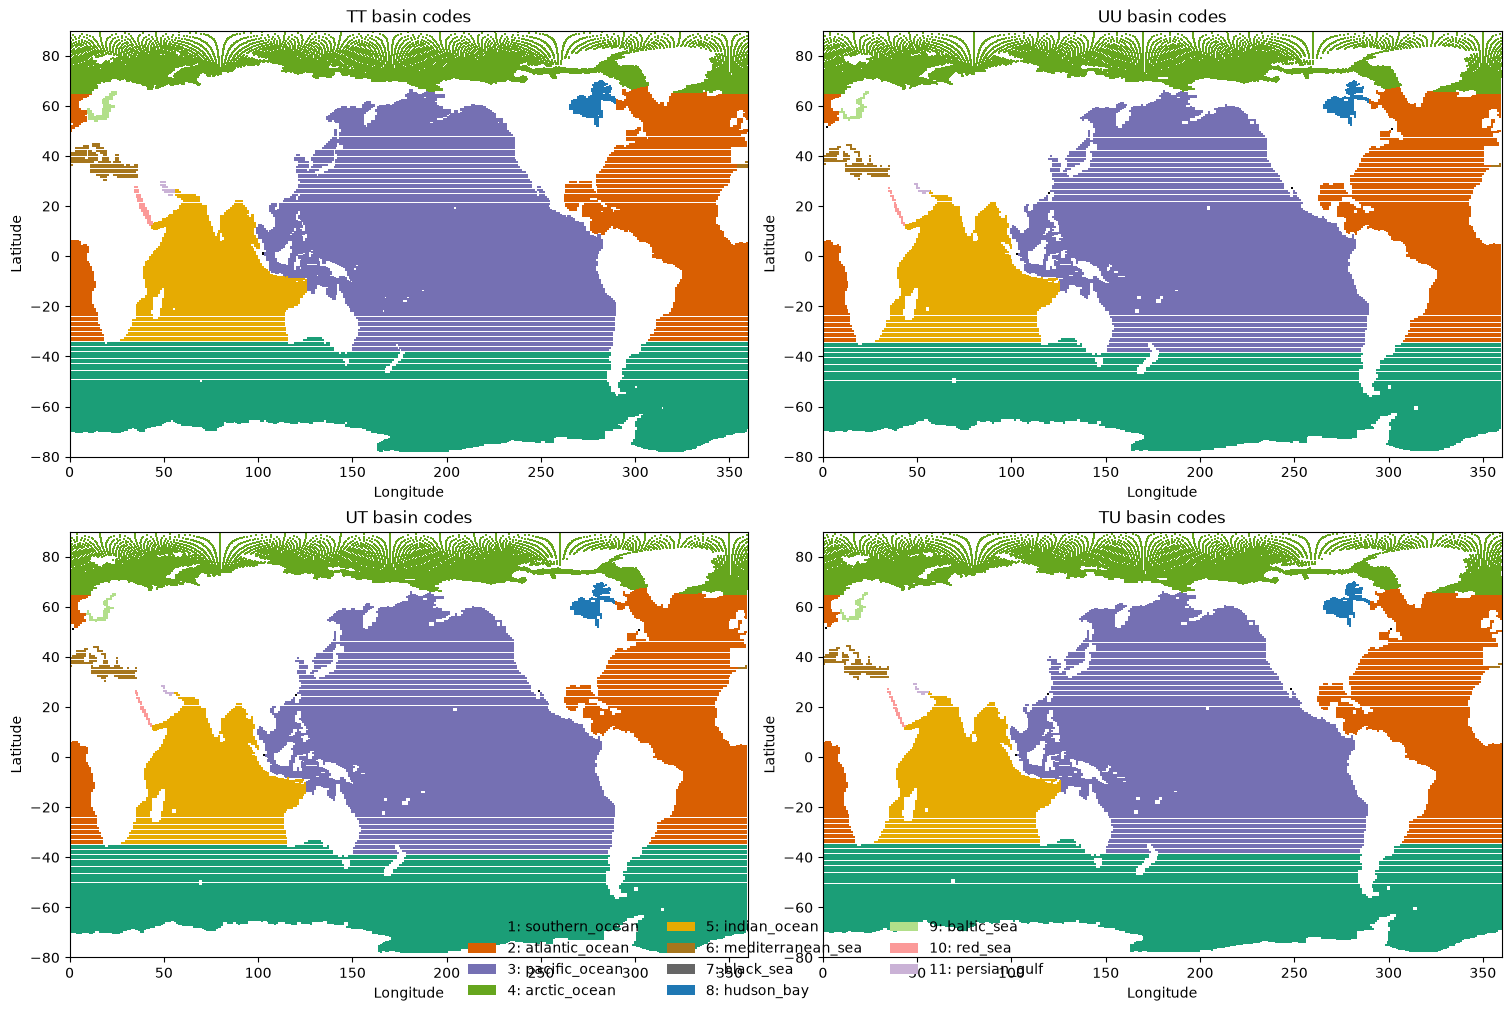

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except Exception:
    HAVE_CARTOPY = False

# MOM6 genBasinMasks code mapping (xda=False).
basin_code_labels = {
    1: "southern_ocean",
    2: "atlantic_ocean",
    3: "pacific_ocean",
    4: "arctic_ocean",
    5: "indian_ocean",
    6: "mediterranean_sea",
    7: "black_sea",
    8: "hudson_bay",
    9: "baltic_sea",
    10: "red_sea",
    11: "persian_gulf",
}

basin_code_colors = {
    1: "#1b9e77",
    2: "#d95f02",
    3: "#7570b3",
    4: "#66a61e",
    5: "#e6ab02",
    6: "#a6761d",
    7: "#666666",
    8: "#1f78b4",
    9: "#b2df8a",
    10: "#fb9a99",
    11: "#cab2d6",
}

def _plot_basin(ax, lon2d, lat2d, basin2d, title):
    lon = np.asarray(lon2d.values, dtype=float).ravel()
    lat = np.asarray(lat2d.values, dtype=float).ravel()
    basin = np.asarray(basin2d.values, dtype=float).ravel()
    valid = np.isfinite(basin)
    basin_codes = basin[valid].astype(int)
    plot_kwargs = dict(s=2, marker=",", linewidths=0)
    if HAVE_CARTOPY:
        plot_kwargs["transform"] = ccrs.PlateCarree()

    for code in sorted(np.unique(basin_codes)):
        code_mask = basin_codes == code
        ax.scatter(
            lon[valid][code_mask],
            lat[valid][code_mask],
            color=basin_code_colors.get(int(code), "#000000"),
            **plot_kwargs,
        )

    ax.set_title(title)
    if HAVE_CARTOPY:
        ax.coastlines(linewidth=0.6)
        ax.add_feature(cfeature.LAND, facecolor="white", zorder=3)
        ax.set_global()
    else:
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

if HAVE_CARTOPY:
    fig, axs = plt.subplots(2, 2, figsize=(15, 10), subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)
else:
    fig, axs = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

_plot_basin(axs[0, 0], lon_tt, lat_tt, basin_tt, "TT basin codes")
_plot_basin(axs[0, 1], lon_uu, lat_uu, basin_uu, "UU basin codes")
_plot_basin(axs[1, 0], lon_ut, lat_ut, basin_ut, "UT basin codes")
_plot_basin(axs[1, 1], lon_tu, lat_tu, basin_tu, "TU basin codes")

legend_handles = [
    Patch(facecolor=basin_code_colors[k], edgecolor="none", label=f"{k}: {basin_code_labels[k]}")
    for k in sorted(basin_code_labels)
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False)

if not HAVE_CARTOPY:
    for ax in axs.ravel():
        ax.set_xlim(0, 360)
        ax.set_ylim(-80, 90)

plt.show()

## 4) Build 3D masks

If `st_ocean` is present, we use it directly. Otherwise we create `1..DEFAULT_NZ`.

Vertical wetness priority:
- TT: `kmt` (fallback: repeat 2D wet mask)
- UU: `kmu` then `kmt` (fallback: repeat 2D wet mask)
- UT/TU: `kmt` (fallback: repeat 2D wet mask)

In [12]:
if "st_ocean" in ds.variables:
    st_ocean = ds["st_ocean"]
else:
    st_ocean = xr.DataArray(np.arange(1, DEFAULT_NZ + 1, dtype=np.float64), dims=("st_ocean",), name="st_ocean")
    st_ocean.attrs.update({"long_name": "depth level index", "units": "1", "positive": "down"})

wet3d_tt = build_wet3d_from_k(ds, wet_tt, y_tt, x_tt, st_ocean, ["kmt"])
wet3d_uu = build_wet3d_from_k(ds, wet_uu, y_uu, x_uu, st_ocean, ["kmu", "kmt"])
wet3d_ut = build_wet3d_from_k(ds, wet_ut, y_ut, x_ut, st_ocean, ["kmt"])
wet3d_tu = build_wet3d_from_k(ds, wet_tu, y_tu, x_tu, st_ocean, ["kmt"])

mask_ttcell = make_mask_var(
    basin_tt, wet3d_tt, "mask_ttcell", "ttcell basin mask", "geolon_t geolat_t"
)
mask_uucell = make_mask_var(
    basin_uu, wet3d_uu, "mask_uucell", "uucell basin mask", "geolon_c geolat_c",
    standard_name="sea_water_x_velocity"
)
mask_utcell = make_mask_var(
    basin_ut, wet3d_ut, "mask_utcell", "utcell basin mask", "geolon_c geolat_t",
    standard_name="ocean_x_mass_transport"
)
mask_tucell = make_mask_var(
    basin_tu, wet3d_tu, "mask_tucell", "tucell basin mask", "geolon_t geolat_c",
    standard_name="ocean_y_mass_transport"
)

## 5) Assemble and save NetCDF

This writes a file with dimensions analogous to your reference file.

In [13]:
def _coord_or_index(ds, name, size):
    if name in ds.variables:
        return ds[name]
    return xr.DataArray(np.arange(size, dtype=np.float64), dims=(name,), name=name)

yt_ocean = _coord_or_index(ds, "yt_ocean", mask_ttcell.sizes[y_tt])
xt_ocean = _coord_or_index(ds, "xt_ocean", mask_ttcell.sizes[x_tt])
yu_ocean = _coord_or_index(ds, "yu_ocean", mask_uucell.sizes[y_uu])
xu_ocean = _coord_or_index(ds, "xu_ocean", mask_uucell.sizes[x_uu])

mask_ttcell = mask_ttcell.rename({y_tt: "yt_ocean", x_tt: "xt_ocean"})
mask_uucell = mask_uucell.rename({y_uu: "yu_ocean", x_uu: "xu_ocean"})
mask_utcell = mask_utcell.rename({y_ut: "yt_ocean", x_ut: "xu_ocean"})
mask_tucell = mask_tucell.rename({y_tu: "yu_ocean", x_tu: "xt_ocean"})

ds_out = xr.Dataset(
    data_vars={
        "mask_ttcell": mask_ttcell,
        "mask_uucell": mask_uucell,
        "mask_utcell": mask_utcell,
        "mask_tucell": mask_tucell,
    },
    coords={
        "st_ocean": st_ocean,
        "yt_ocean": yt_ocean,
        "xt_ocean": xt_ocean,
        "yu_ocean": yu_ocean,
        "xu_ocean": xu_ocean,
    },
)

mask_vars = ["mask_ttcell", "mask_uucell", "mask_utcell", "mask_tucell"]

for name in mask_vars:
    ds_out[name].attrs.pop("_FillValue", None)
    ds_out[name].attrs.pop("missing_value", None)

encoding = {
    name: {
        "_FillValue": np.float32(FILL_VALUE),
        "missing_value": np.float32(FILL_VALUE),
        "dtype": "float32",
    }
    for name in mask_vars
}

ds_out.to_netcdf(OUTPUT_FILE, encoding=encoding)

ds_out.to_netcdf(OUTPUT_FILE, encoding=encoding)
print(f"Wrote: {OUTPUT_FILE}")
print(ds_out)

Wrote: ./lsmask_ACCESS-OM2_1deg_generated.nc
<xarray.Dataset> Size: 86MB
Dimensions:      (st_ocean: 50, yt_ocean: 300, xt_ocean: 360, yu_ocean: 300,
                  xu_ocean: 360)
Coordinates:
  * st_ocean     (st_ocean) float64 400B 1.0 2.0 3.0 4.0 ... 47.0 48.0 49.0 50.0
  * yt_ocean     (yt_ocean) float64 2kB 0.0 1.0 2.0 3.0 ... 297.0 298.0 299.0
  * xt_ocean     (xt_ocean) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
  * yu_ocean     (yu_ocean) float64 2kB 0.0 1.0 2.0 3.0 ... 297.0 298.0 299.0
  * xu_ocean     (xu_ocean) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
Data variables:
    mask_ttcell  (st_ocean, yt_ocean, xt_ocean) float32 22MB -1e+20 ... -1e+20
    mask_uucell  (st_ocean, yu_ocean, xu_ocean) float32 22MB -1e+20 ... -1e+20
    mask_utcell  (st_ocean, yt_ocean, xu_ocean) float32 22MB -1e+20 ... -1e+20
    mask_tucell  (st_ocean, yu_ocean, xt_ocean) float32 22MB -1e+20 ... -1e+20


## 6) Quick sanity checks

Check counts per basin code and confirm expected dimensions.

In [14]:
def counts(arr):
    valid = arr.values[arr.values > 0]
    vals, cnt = np.unique(valid.astype(np.int32), return_counts=True)
    return dict(zip(vals.tolist(), cnt.tolist()))

print("mask_ttcell counts:", counts(ds_out["mask_ttcell"].isel(st_ocean=0)))
print("mask_uucell counts:", counts(ds_out["mask_uucell"].isel(st_ocean=0)))
print("mask_utcell counts:", counts(ds_out["mask_utcell"].isel(st_ocean=0)))
print("mask_tucell counts:", counts(ds_out["mask_tucell"].isel(st_ocean=0)))

mask_ttcell counts: {1: 18086, 2: 10464, 3: 23757, 4: 9327, 5: 7166, 6: 283, 8: 486, 9: 124, 10: 62, 11: 25}
mask_uucell counts: {1: 17521, 2: 10040, 3: 23039, 4: 8845, 5: 6923, 6: 193, 8: 384, 9: 76, 10: 32, 11: 13}
mask_utcell counts: {1: 17521, 2: 10069, 3: 23039, 4: 8815, 5: 6925, 6: 193, 8: 384, 9: 76, 10: 32, 11: 12}
mask_tucell counts: {1: 17521, 2: 10036, 3: 23028, 4: 8846, 5: 6933, 6: 193, 8: 387, 9: 75, 10: 33, 11: 13}
